<a href="https://colab.research.google.com/github/Adithiya2007/Credit-Card-Fraud-detection/blob/main/creditcardfraud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
"""
Credit Card Fraud Detection
Step 1 — Load and inspect the data
"""

import pandas as pd

# ── Load the CSV ─────────────────────────────────────────────────────────────
# Change the path below if your file is in a different folder
df = pd.read_csv("/creditcard.csv")

# ── How big is it? ────────────────────────────────────────────────────────────
print("Shape (rows, columns):", df.shape)

# ── What are the columns? ─────────────────────────────────────────────────────
print("\nColumn names:")
print(df.columns.tolist())

# ── Any missing values? ───────────────────────────────────────────────────────
print("\nMissing values per column:")
print(df.isnull().sum())

# ── What does one row look like? ──────────────────────────────────────────────
print("\nFirst transaction (row 0):")
print(df.iloc[0])
print(df['Class'].value_counts())
print()
print(df['Class'].value_counts(normalize=True) * 100)

Shape (rows, columns): (263383, 31)

Column names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Missing values per column:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       1
V21       1
V22       1
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64

First transaction (row 0):
Time        0.000000
V1         -1.359807
V2         -0.072781
V3          2.536347
V4          1.378155
V5         -0.338321
V6          0.462388
V7          0.239599
V8          0.098698
V9          0.363787
V10         0.090794
V11        -0.551600
V12        -0.617801
V13        -0.991390

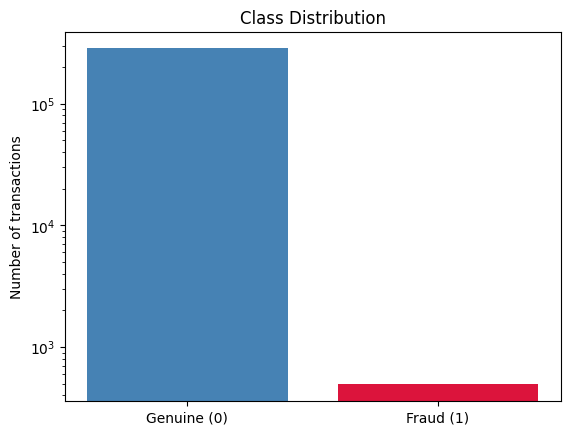

In [2]:
import matplotlib.pyplot as plt

labels = ['Genuine (0)', 'Fraud (1)']
counts = [284315, 492]

plt.bar(labels, counts, color=['steelblue', 'crimson'])
plt.title('Class Distribution')
plt.ylabel('Number of transactions')
plt.yscale('log')  # log scale so fraud bar is actually visible
plt.show()

In [3]:
genuine = df[df['Class'] == 0]['Amount']
fraud   = df[df['Class'] == 1]['Amount']

print("Genuine transactions:")
print(genuine.describe().round(2))

print("\nFraud transactions:")
print(fraud.describe().round(2))

Genuine transactions:
count    262903.00
mean         89.85
std         249.11
min           0.00
25%           5.99
50%          22.80
75%          79.00
max       19656.53
Name: Amount, dtype: float64

Fraud transactions:
count     479.00
mean      121.66
std       258.17
min         0.00
25%         1.00
50%         8.64
75%       105.35
max      2125.87
Name: Amount, dtype: float64


In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df['Amount_Scaled'] = scaler.fit_transform(df[['Amount']])

print(df[['Amount', 'Amount_Scaled']].head(10))

   Amount  Amount_Scaled
0  149.62       0.239703
1    2.69      -0.350072
2  378.66       1.159067
3  123.50       0.134858
4   69.99      -0.079931
5    3.67      -0.346138
6    4.99      -0.340840
7   40.80      -0.197099
8   93.20       0.013234
9    3.68      -0.346098


In [5]:
df = df.drop(columns=['Time', 'Amount'])

print("Remaining columns:", df.shape[1])
print(df.head(3))

Remaining columns: 30
         V1        V2        V3        V4        V5        V6        V7  \
0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   

         V8        V9       V10  ...       V21       V22       V23       V24  \
0  0.098698  0.363787  0.090794  ... -0.018307  0.277838 -0.110474  0.066928   
1  0.085102 -0.255425 -0.166974  ... -0.225775 -0.638672  0.101288 -0.339846   
2  0.247676 -1.514654  0.207643  ...  0.247998  0.771679  0.909412 -0.689281   

        V25       V26       V27       V28  Class  Amount_Scaled  
0  0.128539 -0.189115  0.133558 -0.021053    0.0       0.239703  
1  0.167170  0.125895 -0.008983  0.014724    0.0      -0.350072  
2 -0.327642 -0.139097 -0.055353 -0.059752    0.0       1.159067  

[3 rows x 30 columns]


In [9]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Reload the data fresh
df = pd.read_csv('/creditcard.csv')

# Scale Amount
scaler = StandardScaler()
df['Amount_Scaled'] = scaler.fit_transform(df[['Amount']])

# Drop Time and original Amount
df = df.drop(columns=['Time', 'Amount'])

# Split features and target
X = df.drop(columns=['Class'])
y = df['Class']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:    ", X_test.shape)
print()
print("Fraud cases in training set:", int(y_train.sum()))
print("Fraud cases in test set:    ", int(y_test.sum()))

Training set size: (227845, 29)
Test set size:     (56962, 29)

Fraud cases in training set: 394
Fraud cases in test set:     98


In [ ]:
# Dataset: download creditcard.csv from
# https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

In [14]:
!pip install imbalanced-learn -q

In [15]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(f"  Genuine: {(y_train == 0).sum()}")
print(f"  Fraud:   {(y_train == 1).sum()}")

print("\nAfter SMOTE:")
print(f"  Genuine: {(y_train_sm == 0).sum()}")
print(f"  Fraud:   {(y_train_sm == 1).sum()}")

Before SMOTE:
  Genuine: 227451
  Fraud:   394

After SMOTE:
  Genuine: 227451
  Fraud:   227451


In [16]:
from sklearn.linear_model import LogisticRegression

# Train the model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_sm, y_train_sm)

print("Model trained!")

# Make predictions on the test set
y_pred = model.predict(X_test)
print("Predictions done!")
print(f"\nSample predictions: {y_pred[:20]}")
print(f"Actual labels:      {y_test.values[:20]}")

Model trained!
Predictions done!

Sample predictions: [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
Actual labels:      [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [17]:
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.98     56962

Confusion Matrix:
[[55355  1509]
 [    8    90]]


In [18]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_sm, y_train_sm)

print("Model trained!")

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Model trained!

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
[[56852    12]
 [   17    81]]


In [19]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=100, random_state=42,
                           eval_metric='logloss', n_jobs=-1)
xgb_model.fit(X_train_sm, y_train_sm)

print("Model trained!")

# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

Model trained!

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.69      0.87      0.77        98

    accuracy                           1.00     56962
   macro avg       0.84      0.93      0.88     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
[[56825    39]
 [   13    85]]


In [20]:
# Get probabilities instead of hard predictions
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("First 10 fraud probabilities:")
print(y_proba_rf[:10].round(3))

print("\nActual labels:")
print(y_test.values[:10])

First 10 fraud probabilities:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Actual labels:
[0 0 0 0 0 0 0 0 0 0]


In [21]:
import pandas as pd

# Put probabilities and actual labels together
results = pd.DataFrame({
    'actual': y_test.values,
    'fraud_probability': y_proba_rf
})

# Show the top 10 transactions the model is most suspicious about
print("Top 10 most suspicious transactions:")
print(results.sort_values('fraud_probability', ascending=False).head(10))

Top 10 most suspicious transactions:
       actual  fraud_probability
52728       1                1.0
37511       1                1.0
54930       1                1.0
19638       1                1.0
52778       1                1.0
20472       1                1.0
48945       1                1.0
10623       1                1.0
1146        1                1.0
23090       1                1.0


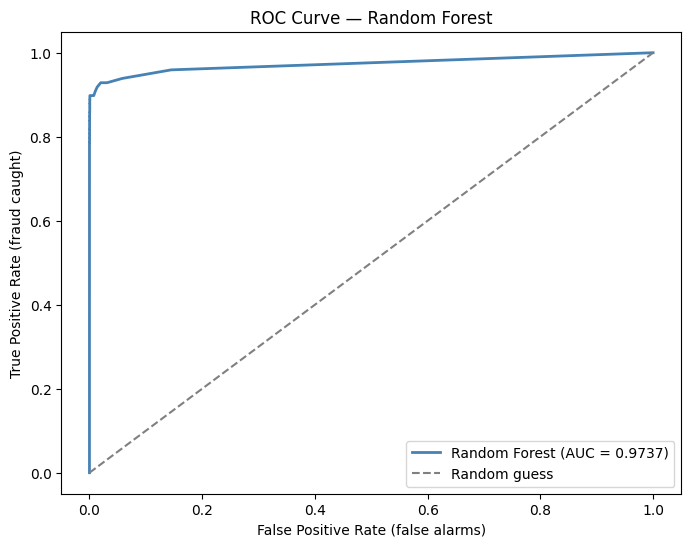


AUC Score: 0.9737


In [22]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba_rf)
auc = roc_auc_score(y_test, y_proba_rf)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', linewidth=2, label=f'Random Forest (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random guess')
plt.xlabel('False Positive Rate (false alarms)')
plt.ylabel('True Positive Rate (fraud caught)')
plt.title('ROC Curve — Random Forest')
plt.legend()
plt.show()

print(f"\nAUC Score: {auc:.4f}")

In [23]:
!pip install shap -q

In [24]:
import shap

# Create explainer
explainer = shap.TreeExplainer(rf_model)

# Calculate SHAP values for the test set
# We use a small sample of 500 to keep it fast
sample = X_test.iloc[:500]
shap_values = explainer.shap_values(sample)

print("SHAP values calculated!")
print("Shape:", shap_values.shape)

SHAP values calculated!
Shape: (500, 29, 2)


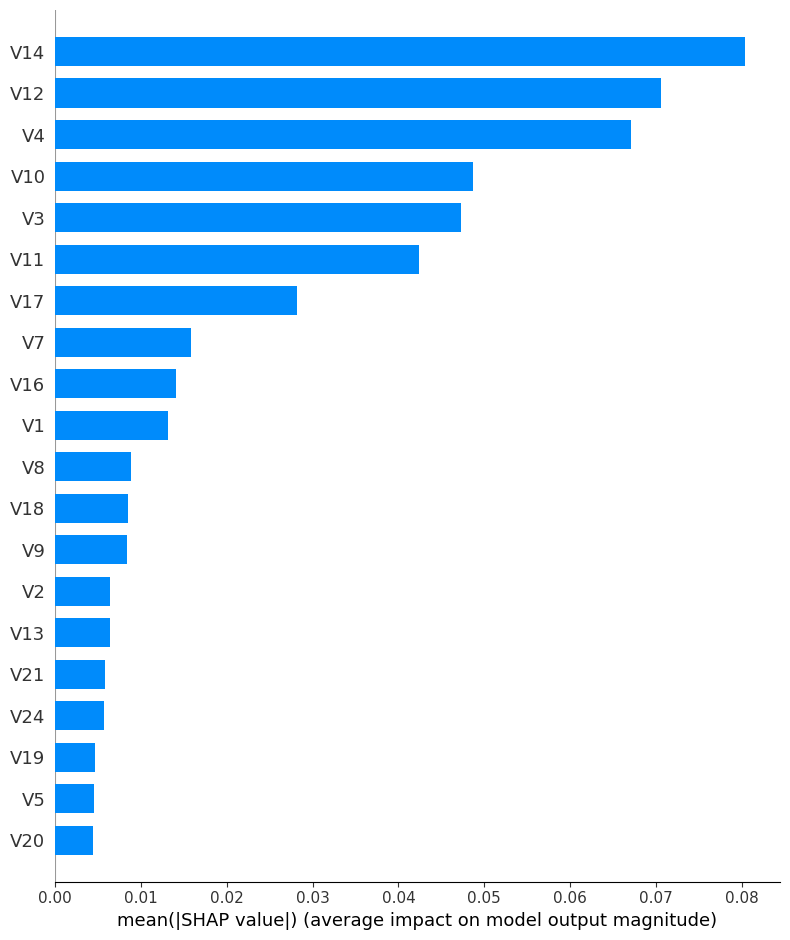

In [25]:
# shap_values[:, :, 1] means we want the fraud class
shap.summary_plot(shap_values[:, :, 1], sample, plot_type="bar")

In [27]:
# Find fraud transactions in the full test set
fraud_positions = [i for i, val in enumerate(y_test.values) if val == 1]
print(f"Found {len(fraud_positions)} fraud cases in test set")
print(f"First fraud is at position: {fraud_positions[0]}")

Found 98 fraud cases in test set
First fraud is at position: 840


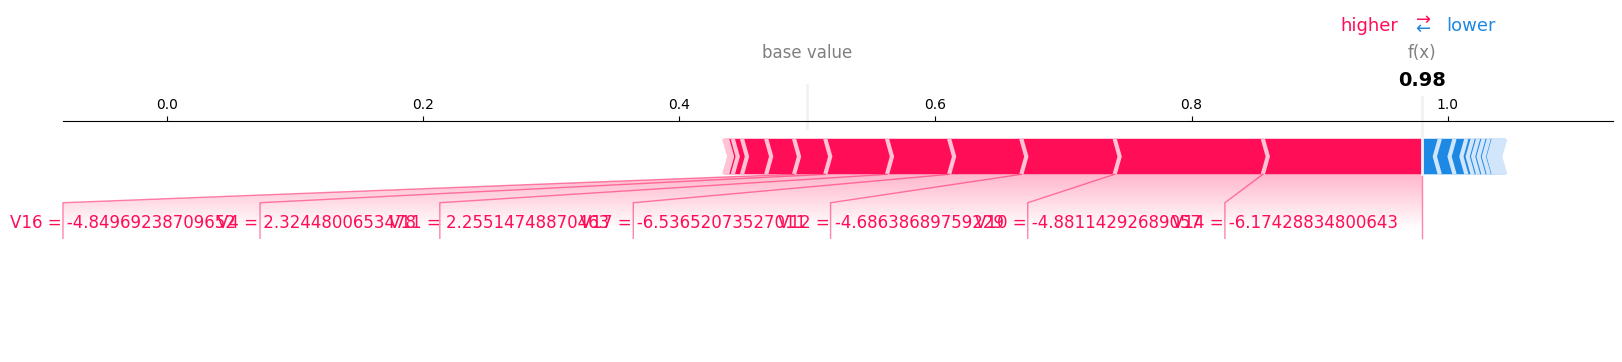

In [28]:
# Take a sample that includes fraud cases
sample = X_test.iloc[800:1000]
shap_values = explainer.shap_values(sample)

# The fraud transaction is at position 840, so it's at index 40 in our sample
fraud_pos = 40

# Plot explanation for that fraud transaction
shap.force_plot(
    explainer.expected_value[1],
    shap_values[fraud_pos, :, 1],
    sample.iloc[fraud_pos],
    matplotlib=True
)

In [29]:
import joblib

# Save the model
joblib.dump(rf_model, 'fraud_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model saved as fraud_model.pkl")
print("Scaler saved as scaler.pkl")

Model saved as fraud_model.pkl
Scaler saved as scaler.pkl


In [30]:
# Load the model back
loaded_model = joblib.load('fraud_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')

# Make a prediction on the first 5 test transactions
test_sample = X_test.iloc[:5]
predictions = loaded_model.predict(test_sample)
probabilities = loaded_model.predict_proba(test_sample)[:, 1]

print("Predictions:   ", predictions)
print("Probabilities: ", probabilities.round(3))
print("Actual labels: ", y_test.values[:5])

Predictions:    [0 0 0 0 0]
Probabilities:  [0. 0. 0. 0. 0.]
Actual labels:  [0 0 0 0 0]


In [31]:
from google.colab import files

files.download('fraud_model.pkl')
files.download('scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
import os

files_saved = os.listdir()
print("Files in Colab:")
for f in files_saved:
    print(f" -", f)

Files in Colab:
 - .config
 - scaler.pkl
 - fraud_model.pkl
 - sample_data


In [33]:
!pip install gradio -q

In [34]:
import gradio as gr
import numpy as np

def predict_fraud(V1, V2, V3, V4, V5, V14, V17, Amount):
    # Scale the amount
    amount_scaled = loaded_scaler.transform([[Amount]])[0][0]

    # Build the feature vector (fill unused features with 0)
    features = np.zeros(29)
    features[0] = V1
    features[1] = V2
    features[2] = V3
    features[3] = V4
    features[4] = V5
    features[13] = V14
    features[16] = V17
    features[28] = amount_scaled

    # Predict
    prob = loaded_model.predict_proba([features])[0][1]
    label = "🚨 FRAUD" if prob > 0.5 else "✅ Genuine"

    return f"{label} (confidence: {prob:.2%})"

# Build the UI
app = gr.Interface(
    fn=predict_fraud,
    inputs=[
        gr.Slider(-10, 10, value=0, label="V1"),
        gr.Slider(-10, 10, value=0, label="V2"),
        gr.Slider(-10, 10, value=0, label="V3"),
        gr.Slider(-10, 10, value=0, label="V4"),
        gr.Slider(-10, 10, value=0, label="V5"),
        gr.Slider(-10, 10, value=0, label="V14 (most important!)"),
        gr.Slider(-10, 10, value=0, label="V17"),
        gr.Number(value=100, label="Amount (€)"),
    ],
    outputs=gr.Text(label="Prediction"),
    title="💳 Credit Card Fraud Detector",
    description="Adjust the sliders and click Submit to check if a transaction is fraudulent."
)

app.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e94764b3b6101fcfd2.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
